"""
================================================================================
🫀 STANDALONE 12-LEAD ECG DENOISING & PREPROCESSING DEMO (500 Hz)
================================================================================
This self-contained script demonstrates step-by-step ECG signal denoising for 
3 clinical records across all 12 leads sampled at 500 Hz (5,000 time-steps).

Filtering Pipeline applied to each 12-lead signal:
  1. High-Pass Butterworth Filter (0.5 Hz)  -> Removes Baseline Wander (breathing/motion)
  2. Low-Pass Butterworth Filter (40 Hz)   -> Removes EMG Muscle Artifacts
  3. IIR Notch Filter (50 Hz)               -> Removes Powerline Hum
  4. Discrete Wavelet Denoising (DWT sym8)  -> Removes Random High-Frequency Noise
  5. Per-Lead Z-Score Normalization         -> Zero-Mean Unit-Variance Scaling
================================================================================
"""

In [1]:

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.signal as signal
import pywt
import wfdb


# ==============================================================================
# 1. ECG PREPROCESSOR CLASS (500 Hz Configured)
# ==============================================================================

In [2]:
class StandaloneECGPreprocessor500Hz:
    def __init__(
        self,
        sampling_rate=500,        # 500 samples per second
        highpass_cutoff=0.5,      # Hz
        lowpass_cutoff=40.0,      # Hz
        notch_freq=50.0,          # Hz
        notch_q=30.0,             # Quality factor
        apply_wavelet=True,
        wavelet_name="sym8",
        wavelet_level=5,          # Level 5 for 500 Hz (since 500 / 2^5 = 15.6 Hz)
        normalize="zscore"
    ):
        self.fs = sampling_rate
        self.highpass_cutoff = highpass_cutoff
        self.lowpass_cutoff = lowpass_cutoff
        self.notch_freq = notch_freq
        self.notch_q = notch_q
        self.apply_wavelet = apply_wavelet
        self.wavelet_name = wavelet_name
        self.wavelet_level = wavelet_level
        self.normalize_method = normalize

    def remove_baseline_wander(self, sig):
        """High-pass Butterworth filter at 0.5 Hz"""
        nyquist = 0.5 * self.fs
        b, a = signal.butter(5, self.highpass_cutoff / nyquist, btype="highpass")
        return signal.filtfilt(b, a, sig, axis=0)

    def remove_muscle_noise(self, sig):
        """Low-pass Butterworth filter at 40 Hz"""
        nyquist = 0.5 * self.fs
        cutoff = min(self.lowpass_cutoff / nyquist, 0.99)
        b, a = signal.butter(5, cutoff, btype="lowpass")
        return signal.filtfilt(b, a, sig, axis=0)

    def remove_powerline_hum(self, sig):
        """IIR Notch filter at 50 Hz"""
        nyquist = 0.5 * self.fs
        if self.notch_freq >= nyquist:
            return sig
        b, a = signal.iirnotch(self.notch_freq, self.notch_q, fs=self.fs)
        return signal.filtfilt(b, a, sig, axis=0)

    def wavelet_denoise_lead(self, lead_sig):
        """DWT soft-thresholding per lead"""
        try:
            coeffs = pywt.wavedec(lead_sig, self.wavelet_name, level=self.wavelet_level)
            sigma = (1 / 0.6745) * np.median(np.abs(coeffs[-1] - np.median(coeffs[-1])))
            if sigma > 1e-8:
                uthresh = sigma * np.sqrt(2 * np.log(len(lead_sig)))
                new_coeffs = [coeffs[0]] + [
                    pywt.threshold(c, value=uthresh, mode="soft") for c in coeffs[1:]
                ]
                denoised = pywt.waverec(new_coeffs, self.wavelet_name)
                return denoised[: len(lead_sig)].astype(np.float32)
            return lead_sig
        except Exception:
            return lead_sig

    def apply_wavelet_denoising(self, sig):
        """Applies DWT denoising to all 12 leads"""
        denoised = np.zeros_like(sig)
        for lead_idx in range(sig.shape[1]):
            denoised[:, lead_idx] = self.wavelet_denoise_lead(sig[:, lead_idx])
        return denoised

    def zscore_normalize(self, sig):
        """Z-score normalization per lead"""
        mean = np.mean(sig, axis=0, keepdims=True)
        std = np.std(sig, axis=0, keepdims=True)
        std[std == 0] = 1.0
        return (sig - mean) / std

    def process(self, raw_signal):
        """
        Input:  raw_signal of shape (5000, 12)  [5000 time-steps x 12 leads]
        Output: cleaned_signal of shape (5000, 12)
        """
        sig = raw_signal.copy().astype(np.float32)

        # Step 1: Baseline wander removal (0.5 Hz highpass)
        sig = self.remove_baseline_wander(sig)

        # Step 2: EMG muscle artifact removal (40 Hz lowpass)
        sig = self.remove_muscle_noise(sig)

        # Step 3: Powerline 50 Hz hum removal (Notch filter)
        sig = self.remove_powerline_hum(sig)

        # Step 4: Discrete Wavelet Transform soft-thresholding
        if self.apply_wavelet:
            sig = self.apply_wavelet_denoising(sig)

        # Step 5: Per-lead Z-score scaling
        if self.normalize_method == "zscore":
            sig = self.zscore_normalize(sig)

        return sig



# ==============================================================================
# 2. PLOTTING FUNCTION FOR ALL 12 LEADS
# ==============================================================================

In [3]:
def plot_12_lead_ecg(raw_sig, clean_sig, lead_names, record_id, save_path, fs=500):
    """
    Plots all 12 leads of an ECG record (Raw vs. Denoised) side-by-side / overlay.
    """
    time_axis = np.arange(len(raw_sig)) / fs # 10 seconds (0 to 10s)

    fig, axes = plt.subplots(12, 1, figsize=(15, 22), sharex=True)
    fig.suptitle(
        f"12-Lead ECG Denoising Demonstration (Record #{record_id} @ {fs} Hz)\n"
        f"Red: Raw Corrupted Signal | Blue/Navy: Filtered & Denoised Output",
        fontsize=15,
        fontweight="bold",
        y=0.995
    )

    for i in range(12):
        lead_label = lead_names[i] if i < len(lead_names) else f"Lead {i+1}"
        axes[i].plot(time_axis, raw_sig[:, i], label="Raw Signal", color="#e63946", alpha=0.5, linewidth=1.0)
        axes[i].plot(time_axis, clean_sig[:, i], label="Denoised Signal", color="#1d3557", linewidth=1.4)
        axes[i].set_ylabel(f"{lead_label}\n(mV)", fontsize=9, fontweight="bold")
        axes[i].legend(loc="upper right", fontsize=8)
        axes[i].grid(True, linestyle="--", alpha=0.5)

    axes[-1].set_xlabel("Time (seconds)", fontsize=12, fontweight="bold")
    plt.tight_layout()
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    plt.savefig(save_path, dpi=300)
    plt.close()
    print(f"Saved 12-lead plot for Record #{record_id} to: {save_path}")



# ==============================================================================
# 3. MAIN EXECUTION (Processes  Records @ 500 Hz)
# ==============================================================================

In [4]:


import matplotlib.pyplot as plt
from tqdm import tqdm


def main():
    raw_dir = "dataset/"
    out_dir = "dataset_denoised/"
    db_path = "dataset/ptbxl_database.csv"

    RESUME = True      # skip records already written

    if not os.path.exists(db_path):
        print(f"Error: Dataset metadata not found at {db_path}.")
        return

    df = pd.read_csv(db_path, index_col="ecg_id")
    print(f"Loaded PTB-XL metadata ({len(df)} total records).")

    preprocessor = StandaloneECGPreprocessor500Hz(sampling_rate=500)

    record_ids = df.index


    print("\n" + "=" * 70)
    print(f"DENOISING {len(record_ids)} 12-LEAD RECORDS (500 Hz)")
    print(f"Output root: {out_dir}")
    print("=" * 70)

    n_done, n_skipped, n_failed = 0, 0, 0

    for idx, ecg_id in enumerate(tqdm(record_ids, desc="Denoising", unit="rec"), 1):
        fn_500hz = df.at[ecg_id, "filename_hr"]   # e.g. records500/00000/00001_hr
        full_path = os.path.join(raw_dir, fn_500hz)

        rec_name = os.path.basename(fn_500hz)                 # 00001_hr
        rec_subdir = os.path.dirname(fn_500hz)                # records500/00000
        write_dir = os.path.join(out_dir, rec_subdir)
        os.makedirs(write_dir, exist_ok=True)

        if RESUME and os.path.exists(os.path.join(write_dir, rec_name + ".hea")):
            n_skipped += 1
            continue

        try:
            record = wfdb.rdrecord(full_path)                 # keeps units/fmt/sig_name
            raw_signal = record.p_signal                      # (5000, 12)
            lead_names = record.sig_name
            sampling_rate = record.fs

            denoised_signal = preprocessor.process(raw_signal)

            wfdb.wrsamp(
                record_name=rec_name,
                fs=int(sampling_rate),
                units=record.units,
                sig_name=lead_names,
                p_signal=np.asarray(denoised_signal, dtype=np.float64),
                fmt=record.fmt,
                comments=record.comments,
                write_dir=write_dir,
            )

            

            n_done += 1

        except Exception as e:
            n_failed += 1
            tqdm.write(f"  [FAIL] ECG ID #{ecg_id} ({fn_500hz}): {e}")

    print("\n" + "=" * 70)
    print(f"COMPLETED — written: {n_done} | skipped: {n_skipped} | failed: {n_failed}")
    print(f"Denoised records: {out_dir}records500/00000 ... 21000/")
    print("=" * 70)


if __name__ == "__main__":
    main()


Loaded PTB-XL metadata (21799 total records).

DENOISING 21799 12-LEAD RECORDS (500 Hz)
Output root: dataset_denoised/


Denoising: 100%|██████████| 21799/21799 [12:21<00:00, 29.42rec/s]


COMPLETED — written: 21799 | skipped: 0 | failed: 0
Denoised records: dataset_denoised/records500/00000 ... 21000/


# ==============================================================================
# 5. FIXED 12-LEAD PLOT - aVR / aVL / aVF were dropped by a case-sensitive lookup
# ==============================================================================
PTB-XL headers spell them `AVR`/`AVL`/`AVF`, so `"aVR" in names` was False and
the three leads were filtered out, leaving 3 blank panels at the bottom.

saved artifacts/eda/denoised_1.png


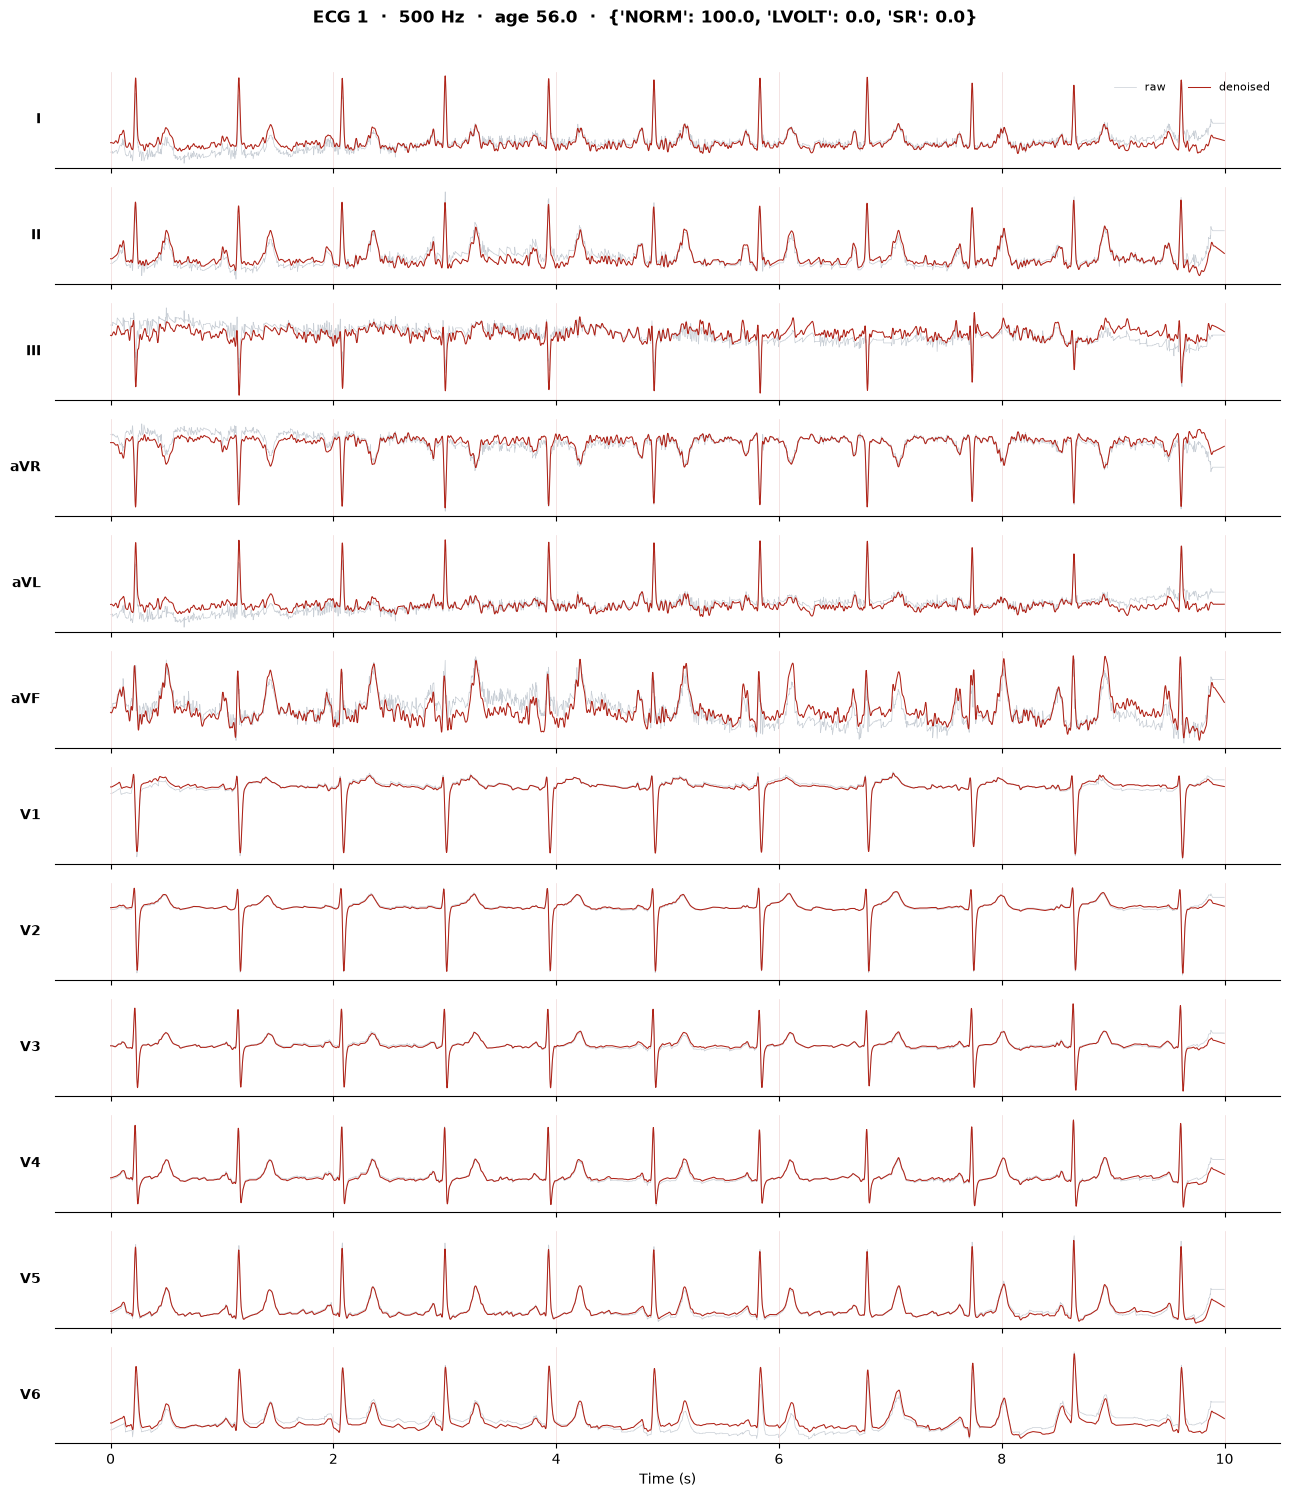

saved artifacts/eda/denoised_2.png


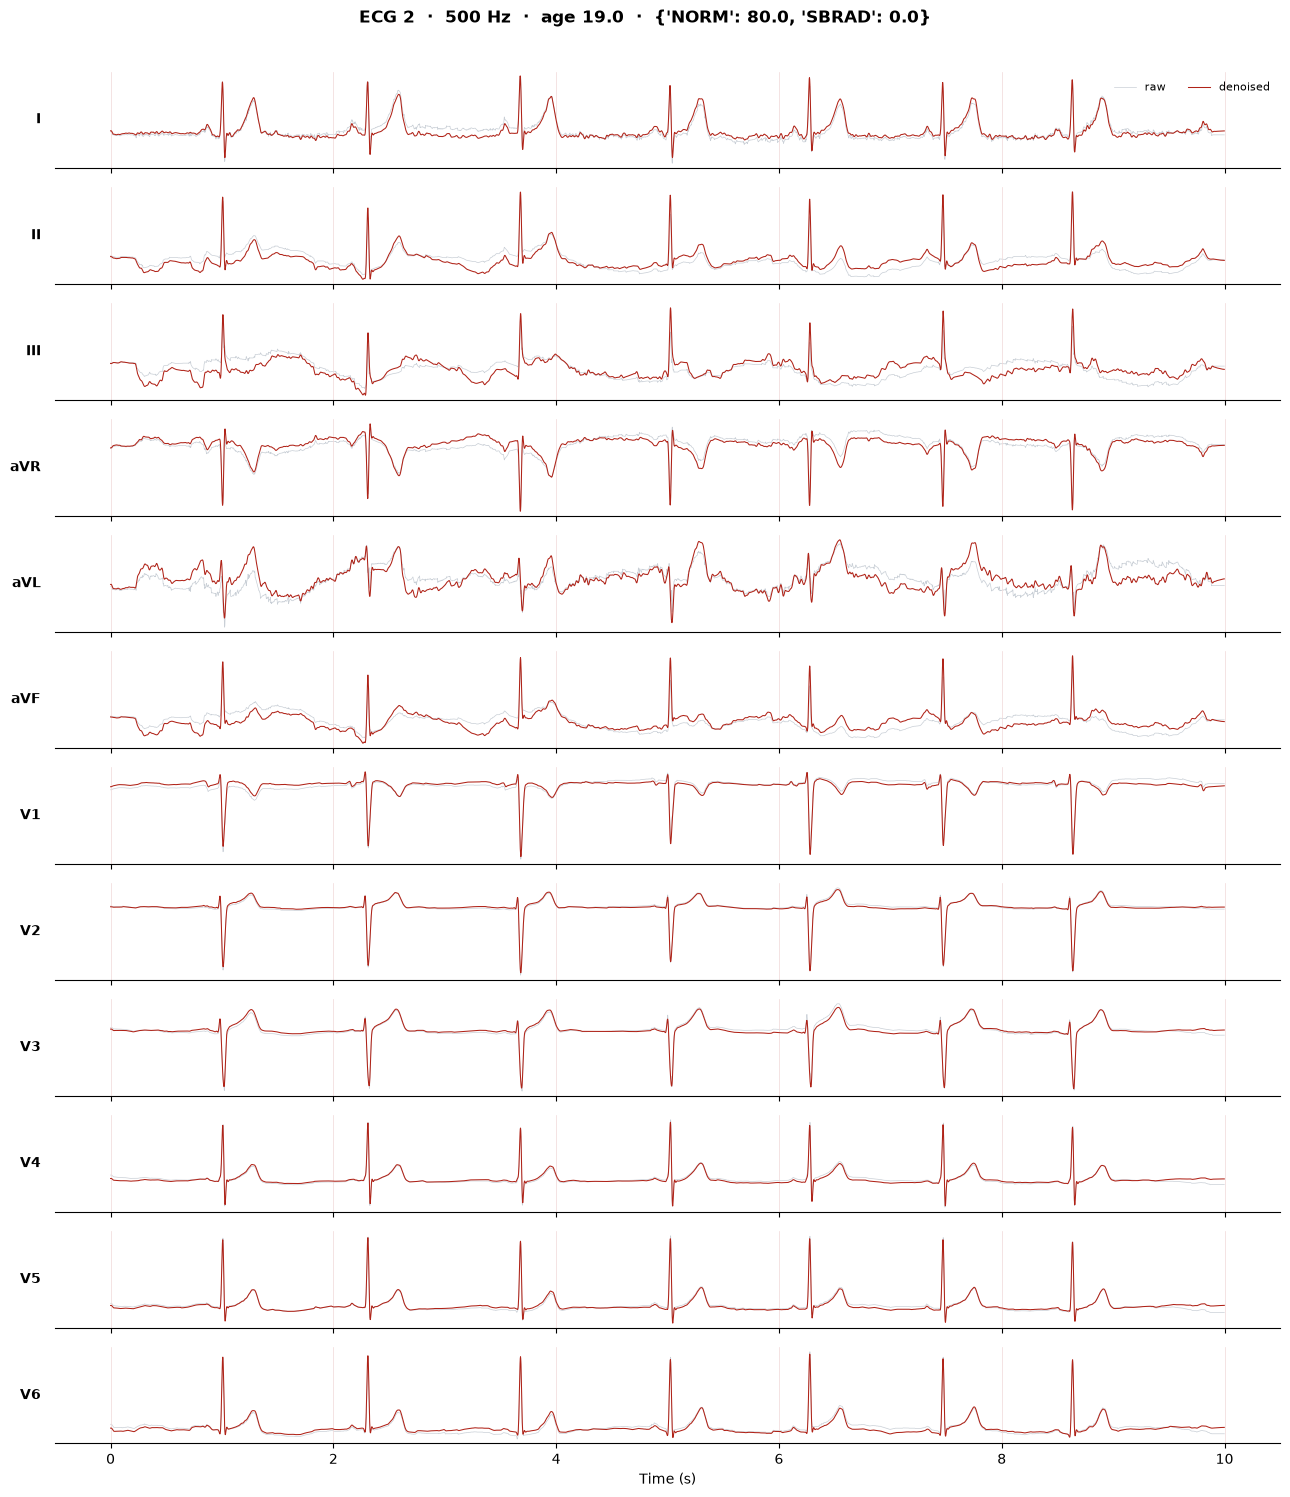

saved artifacts/eda/denoised_3.png


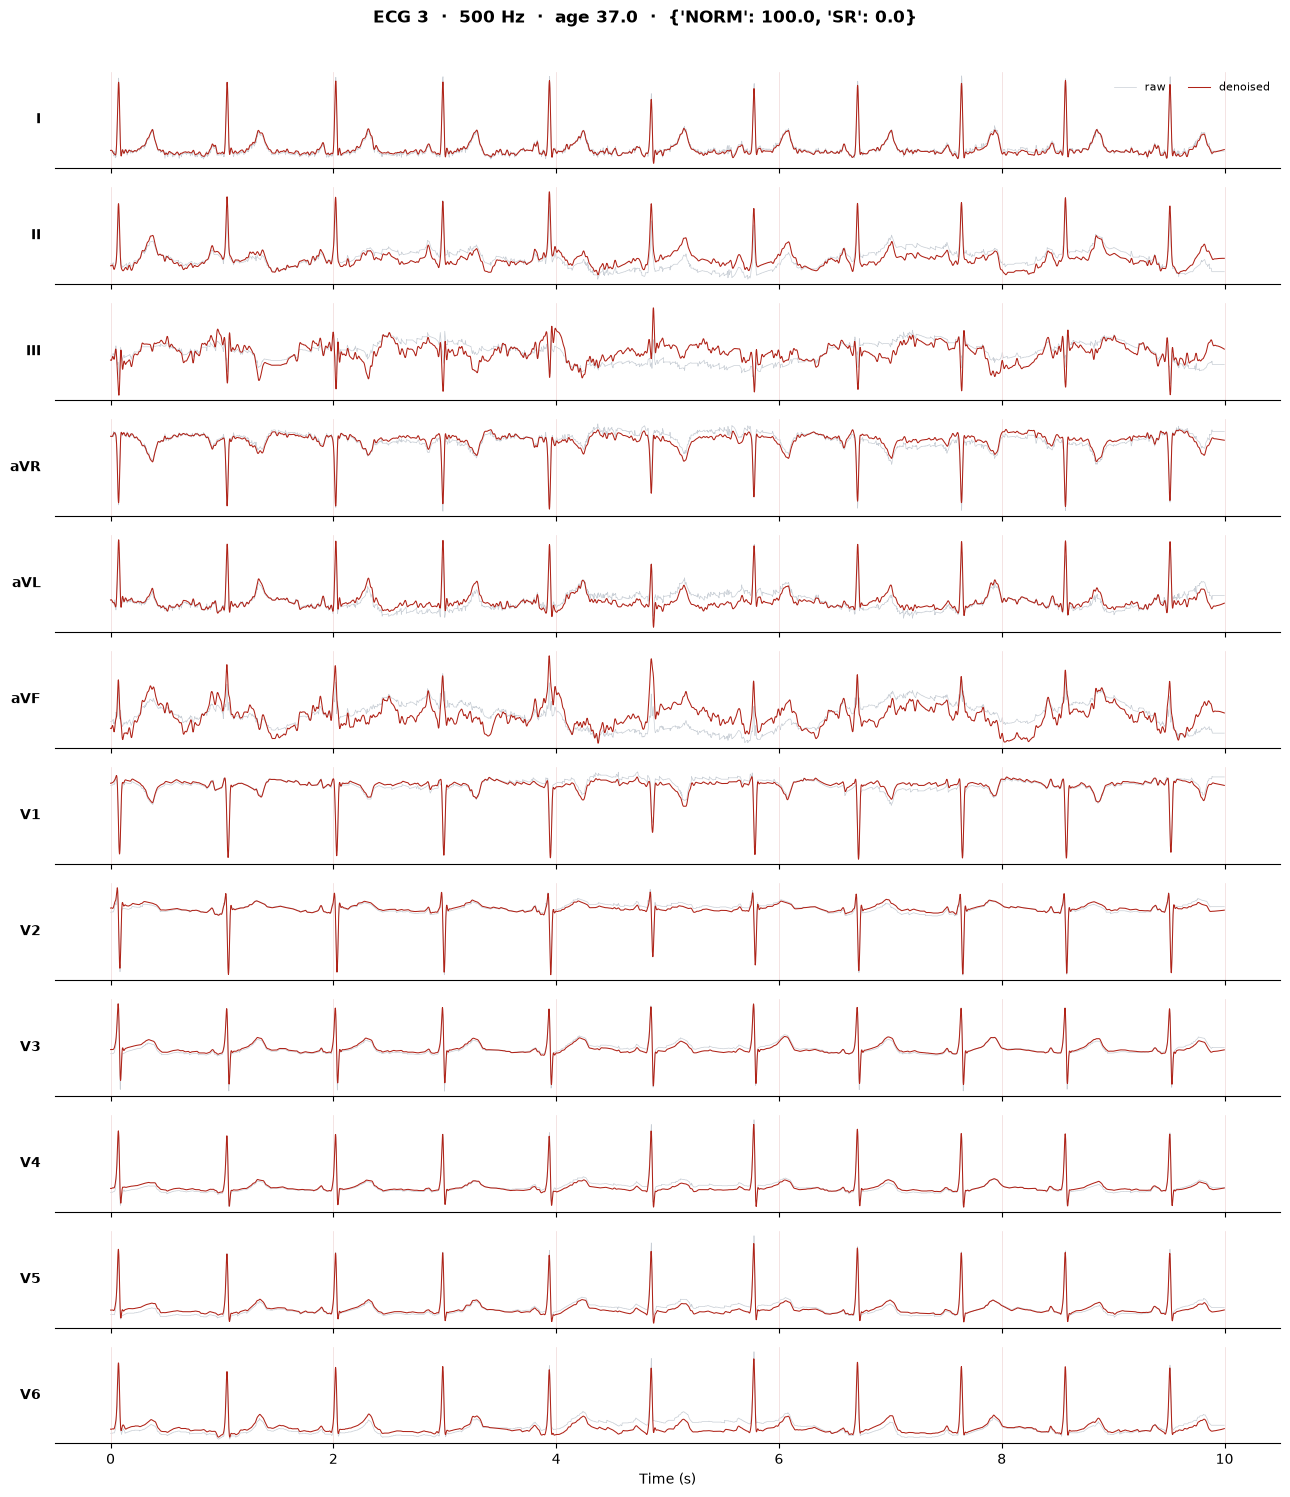

saved artifacts/eda/denoised_4.png


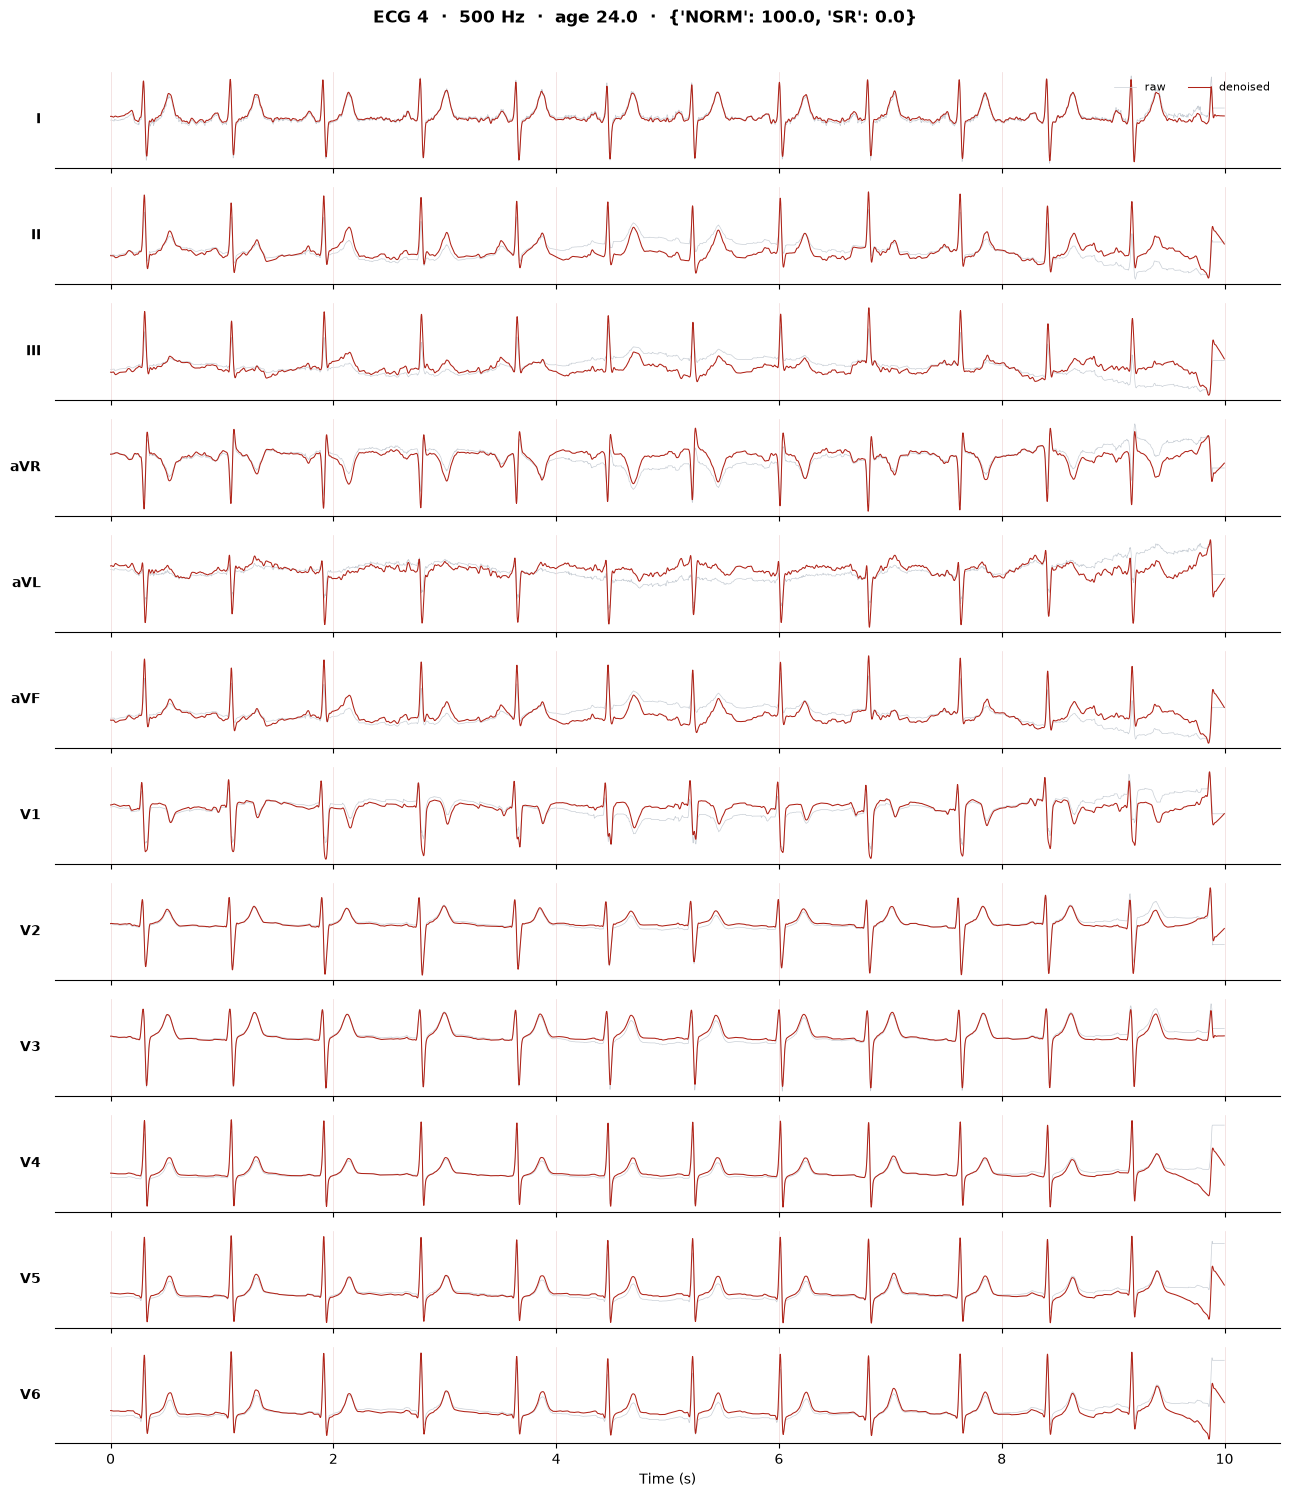

saved artifacts/eda/denoised_5.png


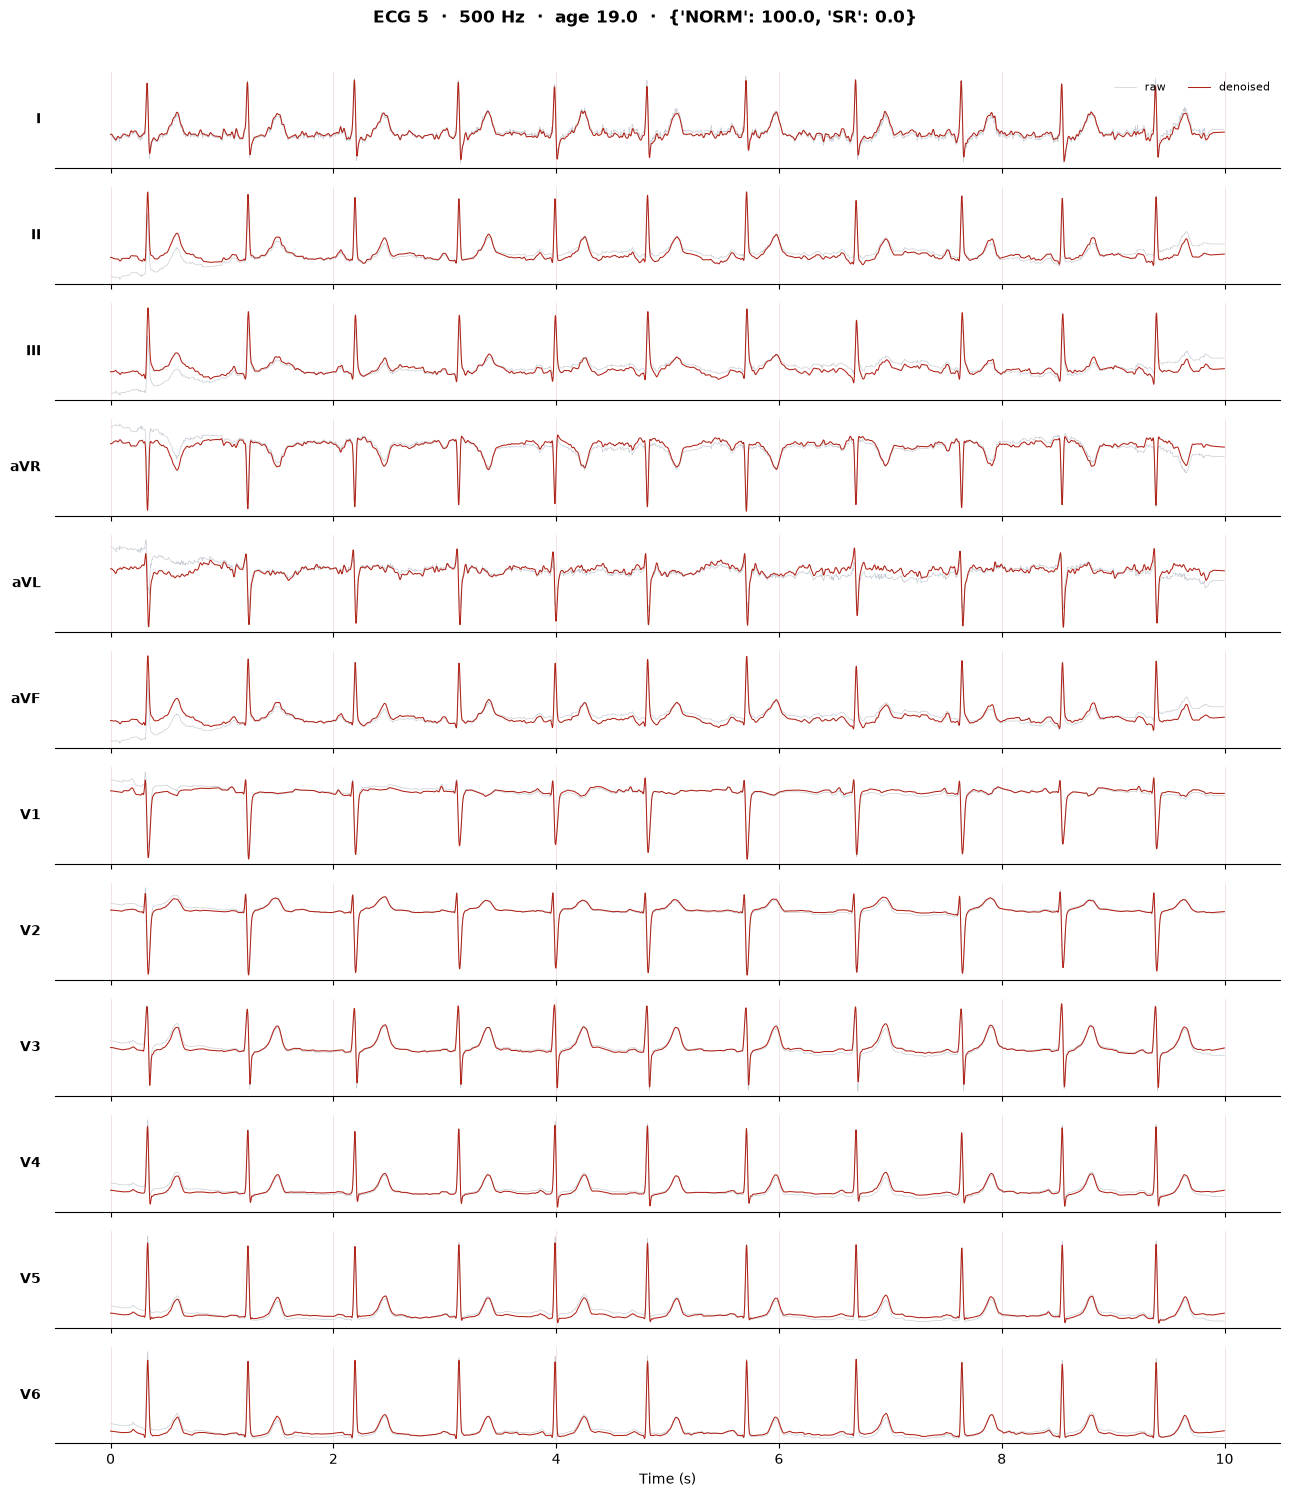

In [13]:
"""Plot 12-lead ECG: raw vs denoised — FIXED lead lookup (all 12 leads).

Bug in the previous cell:

    idx = [names.index(l) for l in LEAD_ORDER if l in names]

PTB-XL headers spell the augmented leads "AVR"/"AVL"/"AVF" (all caps), so
`"aVR" in names` is False. Those three were silently filtered out, idx came
back with only 9 entries, and zip() over 12 axes left the last 3 panels blank.
Match on .upper() instead, and label from LEAD_ORDER (the display spelling)
rather than from the header.
"""
import os
import numpy as np
import pandas as pd
import wfdb
import matplotlib.pyplot as plt

RAW_ROOT = "./dataset"
DEN_ROOT = "./dataset_denoised"
CSV      = "./dataset/ptbxl_database.csv"
OUT_DIR  = "artifacts/eda"
N_PLOT   = 5

LEAD_ORDER = ["I", "II", "III", "aVR", "aVL", "aVF",
              "V1", "V2", "V3", "V4", "V5", "V6"]

# raw is in mV, denoised is z-scored by the pipeline -> put raw on the same
# scale so the overlay is actually comparable. Set False for true mV.
MATCH_SCALE = True


def zscore(sig):
    mean = sig.mean(axis=0, keepdims=True)
    std = sig.std(axis=0, keepdims=True)
    std[std == 0] = 1.0
    return (sig - mean) / std


def lead_channels(names, lead_order=LEAD_ORDER):
    """Display lead names -> channel indices, case-insensitively.

    Raises on a genuinely absent lead instead of dropping it, so a header
    surprise shows up as an error rather than an empty subplot.
    """
    by_name = {n.upper(): i for i, n in enumerate(names)}
    missing = [l for l in lead_order if l.upper() not in by_name]
    if missing:
        raise KeyError(f"leads {missing} not in header {list(names)}")
    return [by_name[l.upper()] for l in lead_order]


def load_pair(ecg_id, df):
    """Return (raw, denoised, lead_names, fs) for one ecg_id."""
    rel = df.at[ecg_id, "filename_hr"]                 # records500/00000/00001_hr
    raw_rec = wfdb.rdrecord(os.path.join(RAW_ROOT, rel))
    den_rec = wfdb.rdrecord(os.path.join(DEN_ROOT, rel))
    return raw_rec.p_signal, den_rec.p_signal, raw_rec.sig_name, raw_rec.fs


def plot_record(ecg_id, df, seconds=None, overlay=True, save=True):
    raw, den, names, fs = load_pair(ecg_id, df)

    n = raw.shape[0] if seconds is None else int(seconds * fs)
    t = np.arange(n) / fs
    raw, den = raw[:n], den[:n]
    if MATCH_SCALE:
        raw = zscore(raw)

    # reorder to clinical lead order regardless of header casing
    idx = lead_channels(names)
    labels = LEAD_ORDER

    fig, axes = plt.subplots(len(idx), 1, figsize=(13, 15), sharex=True)
    for ax, col, lab in zip(axes, idx, labels):
        if overlay:
            ax.plot(t, raw[:, col], lw=0.5, color="#C9CFD6",
                    label="raw", zorder=1)
        ax.plot(t, den[:, col], lw=0.75, color="#B02318",
                label="denoised", zorder=2)
        ax.set_ylabel(lab, rotation=0, ha="right", va="center",
                      fontsize=10, fontweight="bold", labelpad=10)
        ax.grid(True, which="major", color="#F0D8D8", lw=0.5)
        ax.set_yticks([])
        for sp in ("top", "right", "left"):
            ax.spines[sp].set_visible(False)

    axes[0].legend(loc="upper right", fontsize=8, ncol=2, frameon=False)
    axes[-1].set_xlabel("Time (s)", fontsize=10)
    row = df.loc[ecg_id]
    fig.suptitle(f"ECG {ecg_id}  ·  {fs} Hz  ·  age {row.get('age', '?')}  "
                 f"·  {row.get('scp_codes', '')}"[:110],
                 fontsize=12, fontweight="bold", y=0.995)
    fig.tight_layout(rect=[0, 0, 1, 0.985])

    if save:
        os.makedirs(OUT_DIR, exist_ok=True)
        path = f"{OUT_DIR}/denoised_{ecg_id}.png"
        fig.savefig(path, dpi=150, bbox_inches="tight")
        print("saved", path)
    plt.show()
    return fig


df = pd.read_csv(CSV, index_col="ecg_id")
for ecg_id in df.index[:N_PLOT]:
    plot_record(ecg_id, df, seconds=10, overlay=True)
